In [1]:
# Homework 3 - Spam Classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load Dataset
data = pd.read_csv("spambase/spambase.data", header=None)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Same split used throughout Problems 1–3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Optional scaling for manual GD
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Helper metric function
def classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    err = 1 - acc
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        "Accuracy": acc,
        "Error": err,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }



In [2]:
# Problem 1: Logistic Regression
print("PROBLEM 1: LOGISTIC REGRESSION")

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

y_test_pred = log_model.predict(X_test)
y_test_prob = log_model.predict_proba(X_test)[:, 1]

# 1(a) Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\n1(a) Confusion Matrix on Testing Set:")
print(cm)

# 1(b) Accuracy, Error
# 1(c) Precision, Recall, F1
p1_metrics = classification_metrics(y_test, y_test_pred)

print("\n1(b) and 1(c) Testing Metrics:")
for metric_name, metric_value in p1_metrics.items():
    print(f"{metric_name}: {metric_value}")

# 2. Print ALL coefficients
coefficients = pd.Series(log_model.coef_[0], index=[f"Feature_{i}" for i in range(57)])

print("\n2. All Feature Coefficients:")
print(coefficients)

print("\nTop 5 Positive Coefficients:")
print(coefficients.sort_values(ascending=False).head(5))

print("\nTop 5 Negative Coefficients:")
print(coefficients.sort_values().head(5))

# 3. Threshold analysis
thresholds_problem1 = [0.25, 0.5, 0.75, 0.9]
threshold_results = []

print("\n3. Threshold Analysis on Testing Set:")
for t in thresholds_problem1:
    preds_t = (y_test_prob >= t).astype(int)
    metrics_t = classification_metrics(y_test, preds_t)

    threshold_results.append({
        "Threshold": t,
        "Accuracy": metrics_t["Accuracy"],
        "Precision": metrics_t["Precision"],
        "Recall": metrics_t["Recall"]
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))


PROBLEM 1: LOGISTIC REGRESSION

1(a) Confusion Matrix on Testing Set:
[[651  25]
 [ 55 420]]

1(b) and 1(c) Testing Metrics:
Accuracy: 0.9304952215464813
Error: 0.06950477845351866
Precision: 0.9438202247191011
Recall: 0.8842105263157894
F1: 0.9130434782608695

2. All Feature Coefficients:
Feature_0    -0.244349
Feature_1    -0.130202
Feature_2     0.143411
Feature_3     0.753482
Feature_4     0.633717
Feature_5     0.655042
Feature_6     2.110429
Feature_7     0.497044
Feature_8     0.606605
Feature_9     0.078599
Feature_10   -0.369117
Feature_11   -0.094130
Feature_12    0.010730
Feature_13    0.090516
Feature_14    1.503627
Feature_15    1.011050
Feature_16    0.892491
Feature_17    0.087818
Feature_18    0.097390
Feature_19    0.905272
Feature_20    0.240795
Feature_21    0.235278
Feature_22    2.140552
Feature_23    0.369488
Feature_24   -1.814306
Feature_25   -0.759020
Feature_26   -4.195324
Feature_27    0.339735
Feature_28   -1.150492
Feature_29   -0.630457
Feature_30   -0.174

In [3]:
# Problem 2: Gradient Descent for Logistic Regression

print("PROBLEM 2: GRADIENT DESCENT FOR LOGISTIC REGRESSION")


# Helper functions
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def cross_entropy(y_true, y_prob):
    y_prob = np.clip(y_prob, 1e-12, 1 - 1e-12)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def gradient_descent_logistic(X_input, y_input, lr=0.01, iterations=100):
    Xb = np.c_[np.ones(X_input.shape[0]), X_input]
    y_array = np.array(y_input)

    weights = np.zeros(Xb.shape[1])
    losses = []

    for _ in range(iterations):
        z = Xb @ weights
        probs = sigmoid(z)

        gradient = (Xb.T @ (probs - y_array)) / len(y_array)
        weights -= lr * gradient

        current_probs = sigmoid(Xb @ weights)
        loss = cross_entropy(y_array, current_probs)
        losses.append(loss)

    return weights, losses

def predict_from_weights(X_input, weights, threshold=0.5):
    Xb = np.c_[np.ones(X_input.shape[0]), X_input]
    probs = sigmoid(Xb @ weights)
    preds = (probs >= threshold).astype(int)
    return preds, probs

learning_rates = [0.001, 0.01, 0.1]
gd_summary = []

for lr in learning_rates:
    weights, losses = gradient_descent_logistic(
        X_train_scaled, y_train.values, lr=lr, iterations=100
    )

    train_preds_gd, train_probs_gd = predict_from_weights(X_train_scaled, weights)
    test_preds_gd, test_probs_gd = predict_from_weights(X_test_scaled, weights)

    train_metrics_gd = classification_metrics(y_train, train_preds_gd)
    test_metrics_gd = classification_metrics(y_test, test_preds_gd)

    print(f"\nLearning Rate = {lr}")
    print(f"Loss after 10 iterations:  {losses[9]}")
    print(f"Loss after 50 iterations:  {losses[49]}")
    print(f"Loss after 100 iterations: {losses[99]}")

    print("\nTraining Metrics at 100 Iterations:")
    for k, v in train_metrics_gd.items():
        print(f"{k}: {v}")

    print("\nTesting Metrics at 100 Iterations:")
    for k, v in test_metrics_gd.items():
        print(f"{k}: {v}")

    gd_summary.append({
        "Learning Rate": lr,
        "Loss@10": losses[9],
        "Loss@50": losses[49],
        "Loss@100": losses[99],
        "Train Accuracy": train_metrics_gd["Accuracy"],
        "Train Precision": train_metrics_gd["Precision"],
        "Train Recall": train_metrics_gd["Recall"],
        "Train F1": train_metrics_gd["F1"],
        "Test Accuracy": test_metrics_gd["Accuracy"],
        "Test Precision": test_metrics_gd["Precision"],
        "Test Recall": test_metrics_gd["Recall"],
        "Test F1": test_metrics_gd["F1"]
    })

gd_summary_df = pd.DataFrame(gd_summary)

print("\nSummary Table for Gradient Descent:")
print(gd_summary_df.to_string(index=False))

# Compare with package logistic regression on BOTH training and testing sets
package_train_pred = log_model.predict(X_train)
package_test_pred = log_model.predict(X_test)

package_train_metrics = classification_metrics(y_train, package_train_pred)
package_test_metrics = classification_metrics(y_test, package_test_pred)

print("\nComparison with Package Logistic Regression")
print("\nPackage Logistic Regression - Training Metrics:")
for k, v in package_train_metrics.items():
    print(f"{k}: {v}")

print("\nPackage Logistic Regression - Testing Metrics:")
for k, v in package_test_metrics.items():
    print(f"{k}: {v}")


PROBLEM 2: GRADIENT DESCENT FOR LOGISTIC REGRESSION

Learning Rate = 0.001
Loss after 10 iterations:  0.6885826014521534
Loss after 50 iterations:  0.671211570607833
Loss after 100 iterations: 0.6513329933914995

Training Metrics at 100 Iterations:
Accuracy: 0.8959420289855072
Error: 0.10405797101449277
Precision: 0.8607221812822402
Recall: 0.8729446935724963
F1: 0.8667903525046382

Testing Metrics at 100 Iterations:
Accuracy: 0.8992180712423979
Error: 0.10078192875760206
Precision: 0.881104033970276
Recall: 0.8736842105263158
F1: 0.8773784355179705

Learning Rate = 0.01
Loss after 10 iterations:  0.6511669857747713
Loss after 50 iterations:  0.5416199336398837
Loss after 100 iterations: 0.46873406018219876

Training Metrics at 100 Iterations:
Accuracy: 0.8976811594202898
Error: 0.10231884057971019
Precision: 0.8733889310083397
Recall: 0.8609865470852018
F1: 0.8671433948061724

Testing Metrics at 100 Iterations:
Accuracy: 0.9035621198957429
Error: 0.09643788010425713
Precision: 0.90088

PROBLEM 3: COMPARING CLASSIFIERS

1. kNN Cross-Validation Results:
 k  CV Accuracy  CV Error  CV Precision  CV Recall
 1     0.799420  0.200580      0.741945   0.739576
 3     0.802899  0.197101      0.755011   0.727467
 5     0.800000  0.200000      0.749903   0.725159
 7     0.795652  0.204348      0.744335   0.718101
 9     0.784348  0.215652      0.730828   0.700131
11     0.783768  0.216232      0.730584   0.696969
15     0.780290  0.219710      0.725428   0.693885
21     0.761739  0.238261      0.701351   0.668712

Best k (minimum average CV error) = 3

2. Metrics for All 3 Classifiers:

Logistic Regression - Training Metrics:
Accuracy: 0.9289855072463769
Error: 0.07101449275362315
Precision: 0.9266198282591726
Recall: 0.8871449925261584
F1: 0.9064528445971745

Logistic Regression - Testing Metrics:
Accuracy: 0.9304952215464813
Error: 0.06950477845351866
Precision: 0.9438202247191011
Recall: 0.8842105263157894
F1: 0.9130434782608695

LDA - Training Metrics:
Accuracy: 0.8866666666

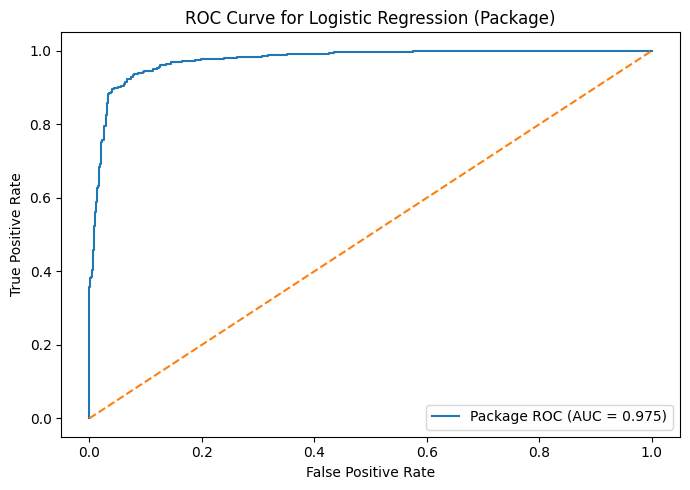


3. AUC for Logistic Regression = 0.9745032700093429

4. Manual ROC Points:
 Threshold      FPR      TPR
       0.0 1.000000 1.000000
       0.1 0.310651 0.985263
       0.2 0.164201 0.972632
       0.3 0.094675 0.943158
       0.4 0.066568 0.922105
       0.5 0.036982 0.884211
       0.6 0.031065 0.827368
       0.7 0.026627 0.787368
       0.8 0.020710 0.715789
       0.9 0.011834 0.589474
       1.0 0.000000 0.000000


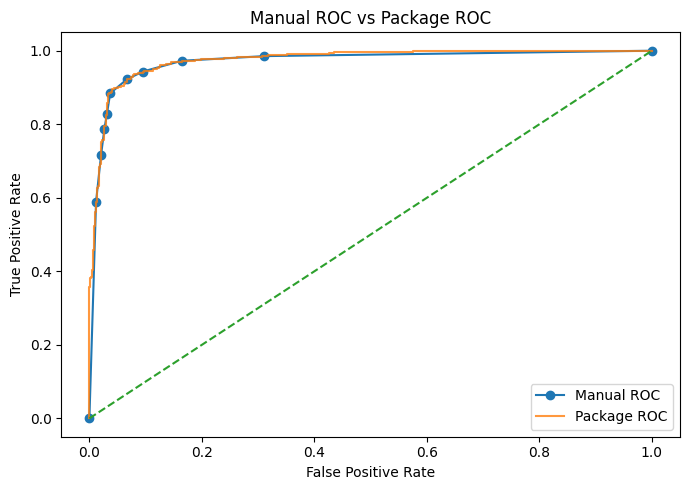

In [4]:
# Problem 3: Comparing Classifiers
print("PROBLEM 3: COMPARING CLASSIFIERS")


# Train Logistic Regression and LDA
log_model_p3 = LogisticRegression(max_iter=5000)
log_model_p3.fit(X_train, y_train)

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

# 1. Cross-validation for kNN
def knn_cv_metrics(X_data, y_data, k_neighbors, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

    accs, errs, precs, recs = [], [], [], []

    for train_idx, val_idx in kf.split(X_data):
        Xtr = X_data.iloc[train_idx]
        Xval = X_data.iloc[val_idx]
        ytr = y_data.iloc[train_idx]
        yval = y_data.iloc[val_idx]

        model = KNeighborsClassifier(n_neighbors=k_neighbors)
        model.fit(Xtr, ytr)
        pred = model.predict(Xval)

        acc = accuracy_score(yval, pred)
        err = 1 - acc
        prec = precision_score(yval, pred, zero_division=0)
        rec = recall_score(yval, pred, zero_division=0)

        accs.append(acc)
        errs.append(err)
        precs.append(prec)
        recs.append(rec)

    return {
        "k": k_neighbors,
        "CV Accuracy": np.mean(accs),
        "CV Error": np.mean(errs),
        "CV Precision": np.mean(precs),
        "CV Recall": np.mean(recs)
    }

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_cv_results = [knn_cv_metrics(X_train, y_train, k) for k in k_values]
knn_cv_df = pd.DataFrame(knn_cv_results)

print("\n1. kNN Cross-Validation Results:")
print(knn_cv_df.to_string(index=False))

best_k = int(knn_cv_df.loc[knn_cv_df["CV Error"].idxmin(), "k"])
print(f"\nBest k (minimum average CV error) = {best_k}")

# Train best kNN
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

# 2. Metrics for all 3 classifiers on BOTH training and testing sets
models = {
    "Logistic Regression": log_model_p3,
    "LDA": lda_model,
    "kNN": best_knn
}

problem3_rows = []

print("\n2. Metrics for All 3 Classifiers:")
for model_name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = classification_metrics(y_train, train_pred)
    test_metrics = classification_metrics(y_test, test_pred)

    print(f"\n{model_name} - Training Metrics:")
    for k, v in train_metrics.items():
        print(f"{k}: {v}")

    print(f"\n{model_name} - Testing Metrics:")
    for k, v in test_metrics.items():
        print(f"{k}: {v}")

    problem3_rows.append({
        "Model": model_name,
        "Set": "Train",
        "Accuracy": train_metrics["Accuracy"],
        "Error": train_metrics["Error"],
        "Precision": train_metrics["Precision"],
        "Recall": train_metrics["Recall"]
    })

    problem3_rows.append({
        "Model": model_name,
        "Set": "Test",
        "Accuracy": test_metrics["Accuracy"],
        "Error": test_metrics["Error"],
        "Precision": test_metrics["Precision"],
        "Recall": test_metrics["Recall"]
    })

problem3_df = pd.DataFrame(problem3_rows)

print("\nSummary Table for Problem 3:")
print(problem3_df.to_string(index=False))

# 3. ROC curve using package
log_probs_test = log_model_p3.predict_proba(X_test)[:, 1]
fpr_pkg, tpr_pkg, _ = roc_curve(y_test, log_probs_test)
roc_auc = auc(fpr_pkg, tpr_pkg)

plt.figure(figsize=(7, 5))
plt.plot(fpr_pkg, tpr_pkg, label=f"Package ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression (Package)")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_package.png")
plt.show()

print(f"\n3. AUC for Logistic Regression = {roc_auc}")

# 4. Manual ROC curve
manual_thresholds = np.arange(0.0, 1.01, 0.1)
manual_roc_rows = []
fpr_manual = []
tpr_manual = []

for t in manual_thresholds:
    preds_t = (log_probs_test >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds_t)
    tn, fp, fn, tp = cm_t.ravel()

    fpr_t = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_t = tp / (tp + fn) if (tp + fn) > 0 else 0

    fpr_manual.append(fpr_t)
    tpr_manual.append(tpr_t)

    manual_roc_rows.append({
        "Threshold": round(t, 2),
        "FPR": fpr_t,
        "TPR": tpr_t
    })

manual_roc_df = pd.DataFrame(manual_roc_rows)

print("\n4. Manual ROC Points:")
print(manual_roc_df.to_string(index=False))

plt.figure(figsize=(7, 5))
plt.plot(fpr_manual, tpr_manual, marker="o", label="Manual ROC")
plt.plot(fpr_pkg, tpr_pkg, label="Package ROC", alpha=0.8)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC vs Package ROC")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_manual_vs_package.png")
plt.show()

In [5]:
# Problem 4: K-Fold Cross Validation
print("PROBLEM 4: CROSS VALIDATION")

def cross_validation_average_error(model, X_data, y_data, k):
    kf = KFold(n_splits=k, shuffle=True, random_state=0)
    fold_errors = []

    for train_idx, val_idx in kf.split(X_data):
        Xtr = X_data.iloc[train_idx]
        Xval = X_data.iloc[val_idx]
        ytr = y_data.iloc[train_idx]
        yval = y_data.iloc[val_idx]

        model.fit(Xtr, ytr)
        preds = model.predict(Xval)

        fold_error = 1 - accuracy_score(yval, preds)
        fold_errors.append(fold_error)

    return fold_errors, np.mean(fold_errors)

problem4_rows = []

for k in [5, 10]:
    log_fold_errors, log_avg_error = cross_validation_average_error(
        LogisticRegression(max_iter=5000), X, y, k
    )
    lda_fold_errors, lda_avg_error = cross_validation_average_error(
        LinearDiscriminantAnalysis(), X, y, k
    )

    print(f"\n{k}-Fold Cross Validation")
    print(f"Logistic Regression Fold Errors: {log_fold_errors}")
    print(f"Logistic Regression Average Validation Error: {log_avg_error}")
    print(f"LDA Fold Errors: {lda_fold_errors}")
    print(f"LDA Average Validation Error: {lda_avg_error}")

    problem4_rows.append({
        "k": k,
        "Model": "Logistic Regression",
        "Average Validation Error": log_avg_error
    })
    problem4_rows.append({
        "k": k,
        "Model": "LDA",
        "Average Validation Error": lda_avg_error
    })

problem4_df = pd.DataFrame(problem4_rows)

print("\nProblem 4 Summary Table:")
print(problem4_df.to_string(index=False))

print("\nConclusion for Problem 4:")
for k in [5, 10]:
    lr_err = problem4_df[
        (problem4_df["k"] == k) & (problem4_df["Model"] == "Logistic Regression")
    ]["Average Validation Error"].values[0]
    lda_err = problem4_df[
        (problem4_df["k"] == k) & (problem4_df["Model"] == "LDA")
    ]["Average Validation Error"].values[0]

    better_model = "Logistic Regression" if lr_err < lda_err else "LDA"
    print(f"For k = {k}, the better model is {better_model}.")

PROBLEM 4: CROSS VALIDATION

5-Fold Cross Validation
Logistic Regression Fold Errors: [0.0890336590662324, 0.07391304347826089, 0.07499999999999996, 0.07065217391304346, 0.05760869565217386]
Logistic Regression Average Validation Error: 0.07324151442194211
LDA Fold Errors: [0.12269272529858855, 0.116304347826087, 0.11739130434782608, 0.1119565217391304, 0.1032608695652174]
LDA Average Validation Error: 0.11432115375536989

10-Fold Cross Validation
Logistic Regression Fold Errors: [0.08242950108459868, 0.09347826086956523, 0.08695652173913049, 0.05869565217391304, 0.06739130434782614, 0.07391304347826089, 0.06521739130434778, 0.08260869565217388, 0.05434782608695654, 0.060869565217391286]
Logistic Regression Average Validation Error: 0.0725907761954164
LDA Fold Errors: [0.11496746203904551, 0.12173913043478257, 0.13043478260869568, 0.09999999999999998, 0.14347826086956517, 0.09130434782608698, 0.09999999999999998, 0.12826086956521743, 0.09999999999999998, 0.11086956521739133]
LDA Averag